## Modeling Objective

The goal of this phase is to develop a rigorous yet practical linear
regression workflow for housing price prediction.

Based on prior preprocessing and EDA, price was found to be strongly
right-skewed. A log transformation is therefore used to better satisfy
linear regression assumptions and improve model stability.

This notebook focuses on:

- developing an initial linear model for `log_price`
- refining predictor structure using theory and predictive performance
- comparing models estimated on the full and trimmed datasets
- selecting a final model specification for inference and diagnostics

In [102]:
# --------------------------------------------------
# Core Libraries
# --------------------------------------------------
import pandas as pd
import numpy as np

# Visualization (used in diagnostics)
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Evaluation metrics
from sklearn.metrics import mean_squared_error, r2_score

# Statistical modeling (inference + VIF)
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', None)

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

### Dataset Setup

Two modeling datasets are used throughout this analysis:

- `outliers_df`: feature-engineered dataset including extreme observations  
- `trimmed_df`: feature-engineered dataset with extreme outliers removed using the previously defined 3×IQR rule  

The full dataset is used initially for model specification, while the trimmed dataset is used to evaluate whether excluding extreme observations improves predictive performance and model stability.

In [103]:
# --------------------------------------------------
# Load Modeling Datasets
# --------------------------------------------------

outliers_df = pd.read_csv("modeling_engineered_full.csv")
trimmed_df = pd.read_csv("modeling_engineered_trimmed.csv")

print("With outliers shape:", outliers_df.shape)
print("Without outliers shape:", trimmed_df.shape)

With outliers shape: (21613, 26)
Without outliers shape: (21096, 26)


### Train/Test Split Strategy

To ensure fair comparison across model specifications, train/test splits
are defined using fixed row indices rather than re-splitting each model
separately.

This approach keeps the evaluation sample constant while allowing
predictor sets to vary across model specifications.

In [104]:
# --------------------------------------------------
# Train/Test Split Strategy
# --------------------------------------------------

# Define fixed train/test indices to ensure consistent evaluation
train_idx, test_idx = train_test_split(
    outliers_df.index,
    test_size=0.2,
    random_state=42
)

train_idx_trim, test_idx_trim = train_test_split(
    trimmed_df.index,
    test_size=0.2,
    random_state=42
)

print(f"Training rows (full dataset): {len(train_idx):,}")
print(f"Test rows (full dataset): {len(test_idx):,}")

print(f"Training rows (trimmed dataset): {len(train_idx_trim):,}")
print(f"Test rows (trimmed dataset): {len(test_idx_trim):,}")

Training rows (full dataset): 17,290
Test rows (full dataset): 4,323
Training rows (trimmed dataset): 16,876
Test rows (trimmed dataset): 4,220


### Model Evaluation Helper Function

A helper function is defined to standardize model estimation and
evaluation across specifications.

It applies fixed train/test splits, fits a linear regression model, and
returns key performance metrics and outputs for comparison and
diagnostics.

In [105]:
# --------------------------------------------------
# Define helper function for model estimation
# --------------------------------------------------

def run_model(
    df,
    dataset_name,
    target,
    predictors,
    train_idx,
    test_idx,
    model_name
):
    """
    Fit a linear regression model and return in-sample and
    out-of-sample metrics.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing target and predictor variables.
    dataset_name : str
        Label identifying which dataset is being used.
    target : str
        Name of dependent variable column.
    predictors : list[str]
        List of predictor column names.
    train_idx : pandas.Index or array-like
        Row indices for the training set.
    test_idx : pandas.Index or array-like
        Row indices for the test set.
    model_name : str
        Label used to identify the model in comparison output.

    Returns
    -------
    dict
        Dictionary containing model metadata, fitted model, and
        performance metrics.
    """
    # Define predictor matrix and target vector
    X = df[predictors]
    y = df[target]

    # Apply fixed train/test split using row indices
    X_train = X.loc[train_idx]
    X_test = X.loc[test_idx]
    y_train = y.loc[train_idx]
    y_test = y.loc[test_idx]

    # Fit linear regression model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Generate predictions for both training and test sets
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate in-sample metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_r2 = r2_score(y_train, y_train_pred)

    # Calculate out-of-sample metrics
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_r2 = r2_score(y_test, y_test_pred)

    # Return results in dictionary form for later comparison
    return {
        "Dataset": dataset_name,
        "Model": model_name,
        "Target": target,
        "Num_Predictors": len(predictors),
        "Predictors": predictors,
        "Train_RMSE": train_rmse,
        "Test_RMSE": test_rmse,
        "Train_R2": train_r2,
        "Test_R2": test_r2,
        "Fitted_Model": model,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "y_train_pred": y_train_pred,
        "y_test_pred": y_test_pred
    }

### Initial Model Search on Full Dataset

Model development began on the full dataset in order to evaluate predictor structure under the most challenging conditions, including extreme observations. This phase was used to test:

- target transformation choice
- structural representation of living area
- redundancy among housing attributes
- whether the model remained stable under outlier-influenced conditions

In [106]:
# --------------------------------------------------
# Baseline Model — Full Dataset (Log Price)
# --------------------------------------------------

spec_baseline_full = {
    "model_name": "Baseline Full (Log)",
    "df": outliers_df,
    "target": "log_price",
    "predictors": [
        "bedrooms",
        "floors",
        "log_sqft_above",
        "log_sqft_basement",
        "bathrooms",
        "grade",
        "condition",
        "house_age",
        "renovated_bool",
        "log_sqft_lot",
        "waterfront",
        "view"
    ],
    "train_idx": train_idx,
    "test_idx": test_idx,
    "dataset_name": "Full"
}

### Baseline Model — Trimmed Dataset

A baseline model is estimated on the trimmed dataset to evaluate model
performance after removing extreme outliers.

This specification reflects the initial feature engineering decisions
while excluding variables identified as redundant or
unstable in the full dataset.

In [107]:
# --------------------------------------------------
# Baseline Model — Trimmed Dataset (Log Price)
# --------------------------------------------------

spec_baseline_trimmed = {
    "model_name": "Baseline Trimmed (Log)",
    "df": trimmed_df,
    "target": "log_price",
    "predictors": [
        "floors",
        "log_sqft_living",
        "bathrooms",
        "grade",
        "condition",
        "house_age",
        "log_sqft_lot",
        "waterfront",
        "view"
    ],
    "train_idx": train_idx_trim,
    "test_idx": test_idx_trim,
    "dataset_name": "Trimmed"
}

### Nonlinear Age Specification — Trimmed Dataset

To capture potential nonlinear lifecycle effects, house age is centered
and a quadratic term is introduced.

Centering reduces structural multicollinearity between the linear and
squared terms, while the quadratic specification allows the model to
capture non-monotonic relationships between age and price.

In [108]:
# --------------------------------------------------
# Nonlinear Age Feature Engineering
# --------------------------------------------------

trimmed_df = trimmed_df.copy()

house_age_mean = trimmed_df["house_age"].mean()
trimmed_df["house_age_c"] = trimmed_df["house_age"] - house_age_mean
trimmed_df["house_age_c_sq"] = trimmed_df["house_age_c"] ** 2


# --------------------------------------------------
# Trimmed Dataset — Nonlinear Age Model (Log Price)
# --------------------------------------------------

spec_nonlinear_age_trimmed = {
    "model_name": "Trimmed + Nonlinear Age (Log)",
    "df": trimmed_df,
    "target": "log_price",
    "predictors": [
        "floors",
        "log_sqft_living",
        "bathrooms",
        "grade",
        "condition",
        "house_age_c",
        "house_age_c_sq",
        "log_sqft_lot",
        "waterfront",
        "view"
    ],
    "train_idx": train_idx_trim,
    "test_idx": test_idx_trim,
    "dataset_name": "Trimmed"
}

### Reduced Model — Drop Bathrooms

Bathrooms are removed to evaluate whether they provide incremental
predictive value beyond other structural and quality-related features.

This step tests for redundancy among housing attributes while aiming to
improve model parsimony without sacrificing predictive performance.

In [109]:
# --------------------------------------------------
# Trimmed Dataset — Drop Bathrooms Model (Log Price)
# --------------------------------------------------

spec_trimmed_drop_bathrooms = {
    "model_name": "Trimmed - Drop Bathrooms (Log)",
    "df": trimmed_df,
    "target": "log_price",
    "predictors": [
        "floors",
        "log_sqft_living",
        "grade",
        "condition",
        "house_age_c",
        "house_age_c_sq",
        "log_sqft_lot",
        "waterfront",
        "view"
    ],
    "train_idx": train_idx_trim,
    "test_idx": test_idx_trim,
    "dataset_name": "Trimmed"
}

### Stress Test — Drop Grade

Grade is removed as a stress test to assess its importance within the
model.

A significant decline in performance would indicate that grade captures
critical information related to construction quality and overall housing
value.

In [110]:
# --------------------------------------------------
# Trimmed Dataset — Drop Grade Model (Log Price)
# --------------------------------------------------

spec_trimmed_drop_grade = {
    "model_name": "Trimmed - Drop Grade (Log)",
    "df": trimmed_df,
    "target": "log_price",
    "predictors": [
        "floors",
        "log_sqft_living",
        "bathrooms",
        "condition",
        "house_age_c",
        "house_age_c_sq",
        "log_sqft_lot",
        "waterfront",
        "view"
    ],
    "train_idx": train_idx_trim,
    "test_idx": test_idx_trim,
    "dataset_name": "Trimmed"
}

### Modeling Results Comparison

Model specifications are evaluated using consistent train/test splits to
ensure comparability across configurations.

Out-of-sample performance is prioritized when selecting the final model,
while in-sample metrics are included for context and diagnostic
purposes.

In [111]:
# --------------------------------------------------
# Run Model Specifications and Compile Results
# --------------------------------------------------

results = []

model_specs = [
    spec_baseline_full,
    spec_baseline_trimmed,
    spec_nonlinear_age_trimmed,
    spec_trimmed_drop_bathrooms,
    spec_trimmed_drop_grade
]

for spec in model_specs:
    result = run_model(
        df=spec["df"],
        dataset_name=spec["dataset_name"],
        target=spec["target"],
        predictors=spec["predictors"],
        train_idx=spec["train_idx"],
        test_idx=spec["test_idx"],
        model_name=spec["model_name"]
    )
    results.append(result)


# --------------------------------------------------
# Compile Results into Comparison Table
# --------------------------------------------------

results_df = pd.DataFrame(results)

display_cols = [
    "Dataset",
    "Model",
    "Target",
    "Num_Predictors",
    "Test_RMSE",
    "Test_R2",
    "Train_RMSE",
    "Train_R2"
]

display(results_df[display_cols].round(4))

,Dataset,Model,Target,Num_Predictors,Test_RMSE,Test_R2,Train_RMSE,Train_R2
0,Full,Baseline Full (Log),log_price,12,0.3127,0.6569,0.3105,0.6499
1,Trimmed,Baseline Trimmed (Log),log_price,9,0.3051,0.5925,0.3069,0.5915
2,Trimmed,Trimmed + Nonlinear Age (Log),log_price,10,0.3046,0.5937,0.3058,0.5944
3,Trimmed,Trimmed - Drop Bathrooms (Log),log_price,9,0.3045,0.5939,0.3067,0.5920
4,Trimmed,Trimmed - Drop Grade (Log),log_price,9,0.3408,0.4915,0.3438,0.4872


### Final Model Selection

Model performance was evaluated primarily using out-of-sample (test)
RMSE and R².

The trimmed model excluding **bathrooms** achieved slightly improved
test performance while reducing model complexity. In contrast, the model
excluding **grade** resulted in a substantial decline in performance,
confirming its importance.

Based on these results, the following predictors were retained in the
final model:

- `floors`
- `log_sqft_living`
- `grade`
- `condition`
- `house_age_c`
- `house_age_c_sq`
- `log_sqft_lot`
- `waterfront`
- `view`

This specification captures structural size, construction quality,
lifecycle effects, and key amenities while excluding redundant
variables.

In [116]:
# --------------------------------------------------
# Identify final model and extract predictors
# --------------------------------------------------

final_model_result = results_df[
    results_df["Model"] == "Trimmed - Drop Bathrooms (Log)"
].iloc[0]

final_predictors = final_model_result["Predictors"]

### Inference and Diagnostics

An OLS regression was fit on the final model specification to evaluate
statistical significance and coefficient behavior.

Variance Inflation Factors (VIF) were also computed to assess
multicollinearity.

In [117]:
# --------------------------------------------------
# Final Model: Inference and Diagnostics
# --------------------------------------------------

# Prepare full trimmed dataset for inference-oriented OLS
X_final = trimmed_df[final_predictors]
y_final = trimmed_df["log_price"]

X_final_sm = sm.add_constant(X_final)

# Fit OLS on the full trimmed dataset
ols_final = sm.OLS(y_final, X_final_sm).fit()
print(ols_final.summary().as_text())

# --------------------------------------------------
# Multicollinearity check (VIF)
# --------------------------------------------------

X_final_vif = sm.add_constant(X_final)

vif_final = pd.DataFrame()
vif_final["Variable"] = X_final_vif.columns
vif_final["VIF"] = [
    variance_inflation_factor(X_final_vif.values, i)
    for i in range(X_final_vif.shape[1])
]

vif_final = vif_final[vif_final["Variable"] != "const"]

display(vif_final.round(2))

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.592
Model:                            OLS   Adj. R-squared:                  0.592
Method:                 Least Squares   F-statistic:                     3406.
Date:                Sun, 29 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:32:43   Log-Likelihood:                -4969.3
No. Observations:               21096   AIC:                             9959.
Df Residuals:                   21086   BIC:                         1.004e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               8.2009      0.047    1

,Variable,VIF
1,floors,2.11
2,log_sqft_living,2.34
3,grade,2.45
4,condition,1.20
5,house_age_c,2.59
6,house_age_c_sq,1.87
7,log_sqft_lot,1.43
8,waterfront,1.13
9,view,1.21


All variables are statistically significant at conventional levels, and
coefficient signs align with economic intuition. VIF values indicate no
severe multicollinearity concerns after centering the age variable.

## Final Model Equation

The estimated model takes the following form:

log(price) = β₀ + Σ βᵢXᵢ

where X includes the selected structural, quality, and lifecycle
features defined above.

In [118]:
params = ols_final.params

equation = "log(price) = "
terms = []

for var, coef in params.items():
    if var == "const":
        terms.append(f"{coef:.4f}")
    else:
        terms.append(f"{coef:.4f}·{var}")

equation += " + ".join(terms)

print(equation)

log(price) = 8.2009 + 0.0417·floors + 0.4213·log_sqft_living + 0.2257·grade + 0.0450·condition + 0.0042·house_age_c + 0.0000·house_age_c_sq + -0.0371·log_sqft_lot + 0.2676·waterfront + 0.0600·view


Because the dependent variable is log-transformed, coefficients for
non-logged predictors can be interpreted as approximate percentage
changes in price for a one-unit increase in the predictor, holding other
variables constant.

### Target Variable Comparison: Log vs Price

To evaluate model fit and interpretability, the final specification is
estimated using both log-transformed price and raw price as the dependent
variable.

For comparability, predictions from the log model are transformed back
into price space and evaluated using dollar-denominated error metrics.

In [119]:
# --------------------------------------------------
# Final Target Comparison — Log vs Price
# --------------------------------------------------

# Run final model using raw price as the target
price_result = run_model(
    df=trimmed_df,
    dataset_name="Trimmed",
    target="price",
    predictors=final_predictors,
    train_idx=train_idx_trim,
    test_idx=test_idx_trim,
    model_name="Final Model (Price)"
)

# Extract test values and predictions from log model
y_test_log = final_model_result["y_test"]
y_pred_log = final_model_result["y_test_pred"]

# Convert to price scale
y_test_price = np.exp(y_test_log)
y_pred_price = np.exp(y_pred_log)

# Compute RMSE in dollars for log model
rmse_price_log_model = np.sqrt(
    mean_squared_error(y_test_price, y_pred_price)
)

# Comparison table (test performance only)
comparison_final = pd.DataFrame({
    "Model": [
        "Final Model (Log → Price)",
        "Final Model (Price)"
    ],
    "RMSE ($)": [
        rmse_price_log_model,
        price_result["Test_RMSE"]
    ],
    "Test_R2": [
        final_model_result["Test_R2"],
        price_result["Test_R2"]
    ]
})

display(comparison_final.round(2))

,Model,RMSE ($),Test_R2
0,Final Model (Log → Price),157455.24,0.59
1,Final Model (Price),159394.04,0.60


The log-transformed model is retained for inference due to improved
stability and more interpretable coefficient behavior.

For practical interpretation, predictions are converted back into price
space, allowing model error to be expressed in dollar terms.

### Residual Interpretation

Model residuals represent deviations between observed and predicted
values and can be interpreted as over- or under-valuation relative to
the model.

In the visualization below, the diagonal line represents perfect
predictions, while the vertical distance from a selected observation to
this line illustrates the residual error.

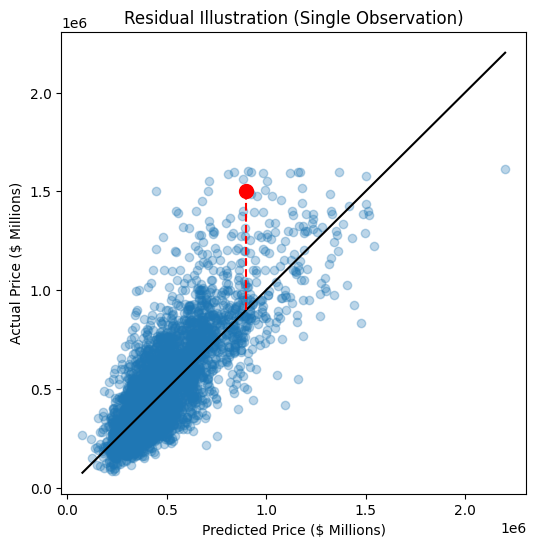

Residual (Actual - Predicted): $600,420


In [123]:
# --------------------------------------------------
# Residual Visualization (Single Observation)
# --------------------------------------------------

# Use converted values from log model
y_true = np.array(y_test_price)
y_pred = np.array(y_pred_price)

# Select a reproducible random observation
np.random.seed(1)
idx = np.random.randint(len(y_true))

# Create plot
plt.figure(figsize=(6, 6))

# Scatter: predicted vs actual
plt.scatter(y_pred, y_true, alpha=0.3)

# Highlight selected observation
plt.scatter(y_pred[idx], y_true[idx], color="red", s=100)

# Reference line (perfect prediction: y = x)
plt.plot(
    [y_pred.min(), y_pred.max()],
    [y_pred.min(), y_pred.max()],
    linestyle="-",
    color="black"
)

# Residual line (vertical distance)
plt.plot(
    [y_pred[idx], y_pred[idx]],
    [y_pred[idx], y_true[idx]],
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Price ($ Millions)")
plt.ylabel("Actual Price ($ Millions)")
plt.title("Residual Illustration (Single Observation)")

plt.show()

# Compute and display residual
residual = y_true[idx] - y_pred[idx]
print(f"Residual (Actual - Predicted): ${residual:,.0f}")